In [1]:
%pip install -qq -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import params

params.configure_renku_cuda()
device = params.select_device()
print(f'Using device: {device}')

Using device: cuda


In [3]:
# Training configuration - modify these parameters as needed
PARAMS = params.Params(
    VARIABLE='tmax',
    MODEL_TYPE='smacnp',         
    DATA_YEAR_START=2023,
    N_EPOCHS=30,
    N_FOLDS=5,
    TRIAL_NAME='test-2023-30e-5f-smacnp-crps-2000sub-altcorrection',
    RUN_TYPE='cloud' if params.is_renku() else 'local',
    BATCH_SIZE=8 if params.is_renku() else 16,
    DEVICE=device,
    SEASONAL_FEATURES=True,
    USE_ELEVATION=True,
    USE_MTPI=True,
    # SMACNP architecture
    R_DIM=128,
    W_DIM=128,
    V_DIM=128,
    N_HEADS=4,
    SMACNP_HIDDEN=128,
    USE_PE=True,
    PE_DIM=32,
)


print(f"Configuration: {PARAMS}")

Configuration: Params(VARIABLE='tmax', DATA_YEAR_START=2023, SEASONAL_FEATURES=True, SEASONAL_FEATURES_IN_MLP=True, USE_ELEVATION=True, USE_MTPI=True, N_CHANNELS=128, N_BLOCKS=6, KERNEL_SIZE=5, LENGTH_SCALE=0.1, IN_CHANNELS=0, N_EPOCHS=30, BATCH_SIZE=8, LR=0.0005, PATIENCE=10, N_FOLDS=5, SEED=42, TRIAL_NAME='test-2023-30e-5f-smacnp-crps-2000sub-altcorrection', RUN_TYPE='cloud', DEVICE=device(type='cuda'), ERA5_MAX_TEMP_GLOB=None, ERA5_GEOPOTENTIAL_GLOB=None, METEO_SWISS_MAX_TEMP_GLOB=None, HI_RES_TOPOGRAPHY_ZARR_PATH=None, MODEL_TYPE='smacnp', R_DIM=128, W_DIM=128, V_DIM=128, N_HEADS=4, SMACNP_HIDDEN=128, USE_PE=True, PE_DIM=32)


In [4]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.optim as optim

import datasets as ds
import model_factory
import cloud_sync
import visualization as vis
from convCNP.training.training_elev import train_smacnp

In [5]:
# Define all paths as local - these are where data will be read from
BASE_DIR = Path('.')
OUTPUT_DIR = BASE_DIR / 'trained_models' / PARAMS.TRIAL_NAME
BASE_DATASET_DIR = BASE_DIR / 'datasets'
REMOTE_OUTPUT_DIR = Path().cwd() / '..' / 'trained-models-mount' / PARAMS.TRIAL_NAME
REMOTE_DATASET_DIR = Path().cwd() / '..' / 'datasets-mount'

# Note: loading datasets on Renkulab directly from Polybox was no working well.
# Things do work if we first sync the files over to local storage and then load them
# locally.
cloud_sync.sync_from_cloud_if_needed(REMOTE_DATASET_DIR, BASE_DATASET_DIR, PARAMS.RUN_TYPE)

# Save data paths in params for reproducibility (used by predictions notebook)
PARAMS = PARAMS.with_data_paths(ds.build_data_paths(BASE_DATASET_DIR))

Cloud run detected. Syncing data from /home/renku/work/convNPClimate/../datasets-mount to datasets...
Synchronizing directory datasets with /home/renku/work/convNPClimate/../datasets-mount
Source directory: /home/renku/work/convNPClimate/../datasets-mount:
dirsync finished in 2.05 seconds.
29 directories parsed, 0 files copied

Dataset sync complete.


In [6]:
# Load ERA5 input data using imported function
train_input_ds, era5_metadata, era5_grid_elevation, time_coords = ds.load_era5_data(
    PARAMS.ERA5_MAX_TEMP_GLOB,
    var_name='t2m_max',
    year_start=PARAMS.DATA_YEAR_START,
    geopotential_glob=PARAMS.ERA5_GEOPOTENTIAL_GLOB,
    geopotential_var_name='z',
    include_seasonal_embeddings=PARAMS.SEASONAL_FEATURES,
    device=device
)

# Track input channels from ERA5 data and update PARAMS
# PARAMS = PARAMS.with_in_channels(train_input_ds.shape[1])
# print(f"IN_CHANNELS set to: {PARAMS.IN_CHANNELS}")

# Compute seasonal features from time coordinates if enabled
# These will be passed to the elevation MLP to learn season-dependent corrections
# SEASONAL_FEATURES=False should disable seasonal features everywhere.
# The model's use_seasonal_in_mlp flag (from SEASONAL_FEATURES_IN_MLP) independently
# controls whether the MLP actually uses these features.
if PARAMS.SEASONAL_FEATURES:
    seasonal_features = ds.compute_seasonal_features(time_coords, device=device)
    print(f"Seasonal features shape: {seasonal_features.shape}  # (time, 2) for [cos_doy, sin_doy]")
else:
    seasonal_features = None
    print("Seasonal features disabled")

Loading ERA5 data from: datasets/ERA5_Land/max_temperature/*.nc
Dataset loaded with dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Original dataset time range: 1960-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset time range from 2023: 2023-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 365, 'latitude': 29, 'longitude': 61})
Calculating stats for t2m_max (Kelvin)...
tensor_Z torch tensor with shape (time, channel, lat, lon): torch.Size([365, 5, 29, 61]), dtype: torch.float32

Loading geopotential data from: datasets/ERA5_Land/geopotential/*.nc
Geopotential dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 1, 'latitude': 51, 'longitude': 81})
Geopotential lat range: [44.0000, 49.0000], shape: (51,)
Geopotential lon range: [4.0000, 12.0000], shape: (81,)
ERA5 data lat range: [45.4000, 48.2000], shape: (29,)
ERA5 data

In [7]:
hi_res_elevation, hi_res_tpi = ds.load_high_res_topography(PARAMS.HI_RES_TOPOGRAPHY_ZARR_PATH)

Loading high-resolution topography from Zarr: datasets/topo_subset.zarr


Topography dataset dimensions: FrozenMappingWarningOnValuesAccess({'y': 12800, 'x': 14200})
DEM shape: (12800, 14200), dtype: int16
TPI (TPI_500M) shape: (12800, 14200), dtype: float32


In [8]:
# Load MeteoSwiss targets using imported function
target_x, target_y, target_topo = ds.prepare_meteoswiss_targets(
    PARAMS.METEO_SWISS_MAX_TEMP_GLOB,
    normalization_stats=era5_metadata,
    data_var='TmaxD',
    grid_elevation=era5_grid_elevation if PARAMS.USE_ELEVATION else None,
    hi_res_elevation=hi_res_elevation if PARAMS.USE_ELEVATION else None,
    hi_res_tpi=hi_res_tpi if PARAMS.USE_MTPI else None,
    convert_to_kelvin=True,
    year_start=PARAMS.DATA_YEAR_START,
    device=device
)

--- Preparing MeteoSwiss Targets (x, y, e) ---
Flattening (240, 370) grid to (point)...
Creating Target Coordinate Tensor (x)...

=== COORDINATE VERIFICATION ===
MeteoSwiss lat (first 5 points): [45.720608 45.720795 45.720974 45.721157 45.721336]
MeteoSwiss lon (first 5 points): [5.8268523 5.839691  5.8525305 5.86537   5.878209 ]
MeteoSwiss lat range: [45.6886, 47.8820]
MeteoSwiss lon range: [5.7613, 10.6919]

ERA5 normalization bounds (should overlap with MeteoSwiss if both in degrees):
ERA5 lat range: [45.4000, 48.2000]
ERA5 lon range: [5.0000, 11.0000]
=== END COORDINATE VERIFICATION ===

Creating Ground Truth Tensor (y) for TmaxD...
  -> Converting Celsius to Kelvin (+273.15) before normalization
Creating Elevation Tensor (e) [3 features]...
  -> Converting target coordinates to Swiss LV95 for hi-res DEM lookup...
  -> Interpolating hi-res DEM at target points...
  -> Interpolating ERA5 grid elevation at target points...
  -> True elevation range: [181.7, 4675.4] m
  -> Grid elevat

In [ ]:
# Build SMACNP context from ERA5 grid
# Flattens tensor → x_context, y_context
x_context, y_context = ds.build_smacnp_context(
    train_input_ds,
)
print(f"x_context: {x_context.shape}   # (T, N_era5_cells, 6)")
print(f"y_context: {y_context.shape}   # (T, N_era5_cells, 1)")

NameError: name 'altitude' is not defined

In [ ]:
params.set_seed(PARAMS.SEED)

In [ ]:
stats_file = os.path.join(OUTPUT_DIR, 'stats.csv')

In [ ]:
# Create output directory if it doesn't exist
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

PARAMS.save_json(output_dir / 'params.json')
ds.save_metadata_json(era5_metadata, output_dir / 'metadata.json')

STATS_HEADER = 'Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL\n'

# Number of MeteoSwiss target points to sample per fold (adjust based on GPU memory)
N_TARGET_POINTS = 2000

# Loop over cross-validation folds
for fold in range(PARAMS.N_FOLDS):
    # if fold in (0,):
    #     # We have already these folds, do just the remaining ones
    #     print(f'Skipping fold {fold + 1}')
    #     continue
    print(f'\nStarting fold {fold + 1}/{PARAMS.N_FOLDS}...\n')

    # --- Subsample MeteoSwiss target points for this fold ---
    # Different random subset per fold so the model sees more of Switzerland across folds.
    target_point_indices = ds.sample_meteoswiss_points(
        torch.from_numpy(target_y.values.astype(np.float32)),
        n_points=N_TARGET_POINTS,
        seed=PARAMS.SEED + fold,
    )
    target_y_subset    = target_y.isel(point=target_point_indices)   # xr: (time, M)
    target_x_subset    = target_x.isel(point=target_point_indices)   # xr: (M, 2)
    target_topo_subset = target_topo[target_point_indices]            # torch: (M, 3)
    x_target, y_target_smacnp = ds.build_smacnp_targets(
        target_x_subset, target_y_subset, target_topo_subset, seasonal_features,
        device=device,
    )
    print(f"  x_target: {x_target.shape}, y_target: {y_target_smacnp.shape}")

    # Per-fold stats file so resumed training doesn't destroy previous results
    fold_stats_file = os.path.join(OUTPUT_DIR, f'stats_fold{fold}.csv')
    if not os.path.exists(fold_stats_file):
        with open(fold_stats_file, 'w') as f:
            f.write(STATS_HEADER)

    # Reset model weights and optimizer for each fold
    params.set_seed(PARAMS.SEED + fold)  # Use a different seed for each fold for robustness
    model, loss_fn, get_value_fn = model_factory.build_smacnp(PARAMS, x_context.shape[-1])
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=PARAMS.LR)

    # Train the model. Note: fold splitting logic is inside train_smacnp
    train_smacnp(
        model=model,
        opt=optimizer,
        ll=loss_fn,
        x_context=x_context,             # (T, N, 6)
        y_context=y_context,             # (T, N, 1)
        x_target=x_target,              # (T, M, 6)
        y_target=y_target_smacnp,        # (T, M)
        output_dir=OUTPUT_DIR,
        get_value=get_value_fn,
        fold=fold,
        n_folds=PARAMS.N_FOLDS,
        n_epochs=PARAMS.N_EPOCHS,
        batch_size=PARAMS.BATCH_SIZE,
        patience=PARAMS.PATIENCE,
        stats_file=fold_stats_file,
        device=device,
    )

    cloud_sync.sync_to_cloud_if_needed(OUTPUT_DIR, REMOTE_OUTPUT_DIR, PARAMS.RUN_TYPE)

# Merge per-fold stats into a single stats.csv
fold_csvs = [os.path.join(OUTPUT_DIR, f'stats_fold{f}.csv') for f in range(PARAMS.N_FOLDS)]
pd.concat([pd.read_csv(p) for p in fold_csvs if os.path.exists(p)]).to_csv(stats_file, index=False)

print(f'\nTraining finished for all {PARAMS.N_FOLDS} folds. Models saved in {output_dir}.')



Starting fold 1/5...

Sampled 4000 MeteoSwiss points from 46718 valid points
  x_target: torch.Size([3652, 4000, 6]), y_target: torch.Size([3652, 4000])
Built SMACNP with 308,995 trainable parameters
Fold 1/5 | Epoch 0 | train NLL 0.139 | test NLL 0.122 | med MAE 0.164 | elapsed 235s | est. remaining 6808s
Fold 1/5 | Epoch 1 | train NLL 0.121 | test NLL 0.117 | med MAE 0.160 | elapsed 469s | est. remaining 6570s
Fold 1/5 | Epoch 2 | train NLL 0.113 | test NLL 0.106 | med MAE 0.147 | elapsed 704s | est. remaining 6334s
Fold 1/5 | Epoch 3 | train NLL 0.105 | test NLL 0.154 | med MAE 0.215 | elapsed 938s | est. remaining 6099s
Fold 1/5 | Epoch 4 | train NLL 0.101 | test NLL 0.106 | med MAE 0.144 | elapsed 1173s | est. remaining 5864s
Fold 1/5 | Epoch 5 | train NLL 0.097 | test NLL 0.105 | med MAE 0.146 | elapsed 1407s | est. remaining 5629s
Fold 1/5 | Epoch 6 | train NLL 0.099 | test NLL 0.114 | med MAE 0.152 | elapsed 1642s | est. remaining 5394s
Fold 1/5 | Epoch 7 | train NLL 0.093 | t

In [ ]:
OUTPUT_DIR
fold_csvs = [os.path.join(OUTPUT_DIR, f'stats_fold{f}.csv') for f in range(PARAMS.N_FOLDS)]
pd.concat([pd.read_csv(p) for p in fold_csvs if os.path.exists(p)]).to_csv(stats_file, index=False)

In [ ]:
print(stats_file)
stats = pd.read_csv(stats_file)
stats

trained_models/test-2014-30e-5f-smacnp-crps-4000sub/stats.csv


,Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL
0,0,0.164041,0.973720,0.972016,0,0.139277,0.122169
1,0,0.159515,0.976192,0.974159,1,0.120798,0.116541
2,0,0.146546,0.978480,0.976893,2,0.112678,0.105559
3,0,0.214525,0.979233,0.977682,3,0.104958,0.154339
4,0,0.143523,0.979402,0.977490,4,0.100721,0.105532
...,...,...,...,...,...,...,...
139,4,0.124972,0.986467,0.986880,19,0.093428,0.090807
140,4,0.121836,0.987240,0.986990,20,0.076685,0.088744
141,4,0.126462,0.987462,0.987150,21,0.093913,0.094152
142,4,0.122611,0.987176,0.986926,22,0.097390,0.090265


  Saved plot: trained_models/test-2014-30e-5f-smacnp-crps-4000sub/trainingstats_fold0


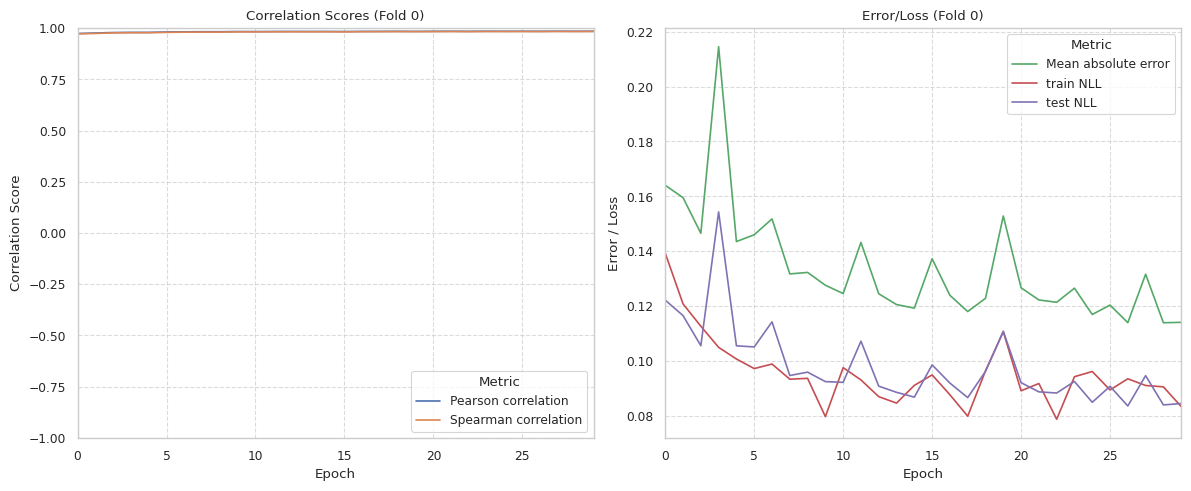

  Saved plot: trained_models/test-2014-30e-5f-smacnp-crps-4000sub/trainingstats_fold1


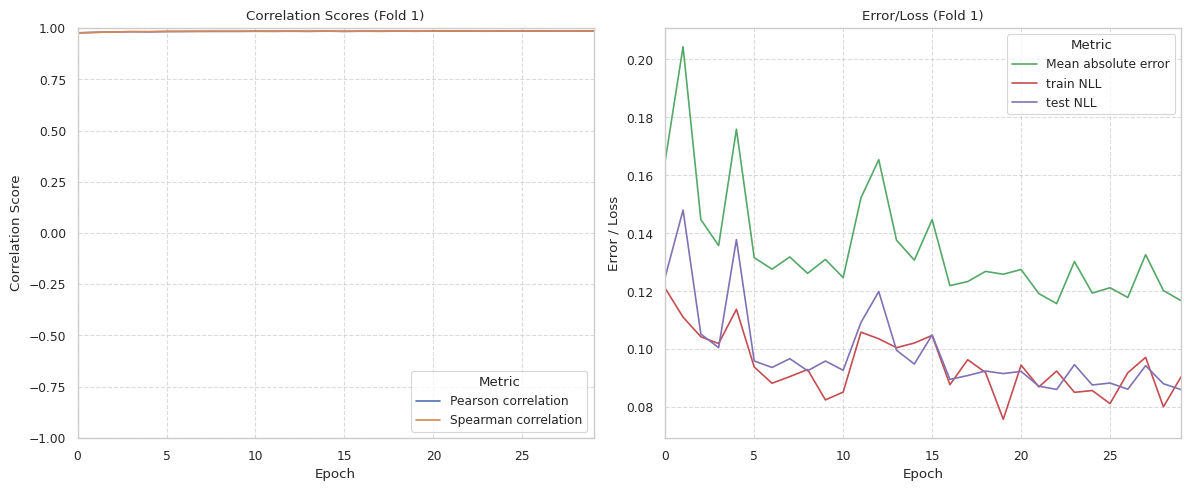

  Saved plot: trained_models/test-2014-30e-5f-smacnp-crps-4000sub/trainingstats_fold2


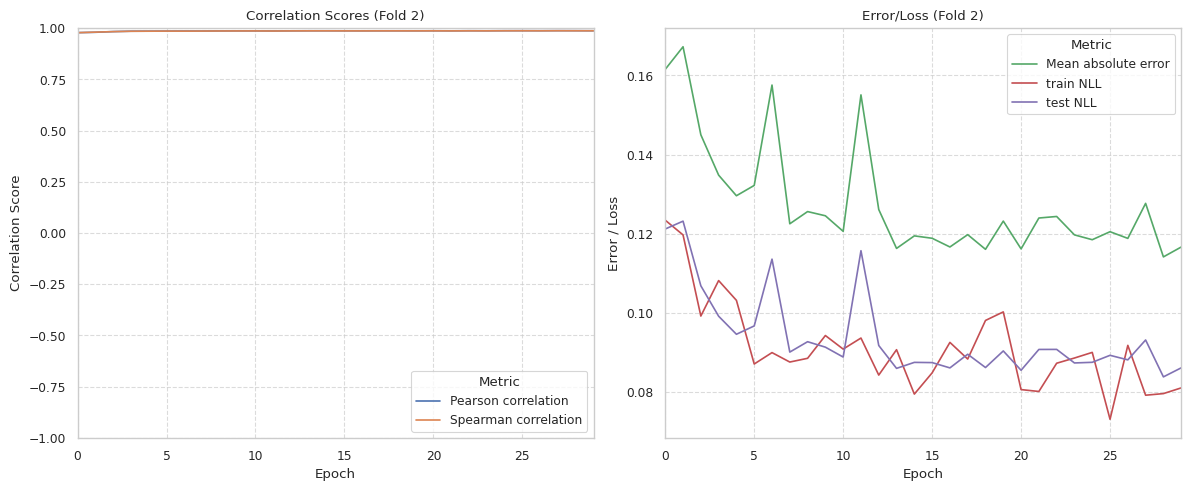

  Saved plot: trained_models/test-2014-30e-5f-smacnp-crps-4000sub/trainingstats_fold3


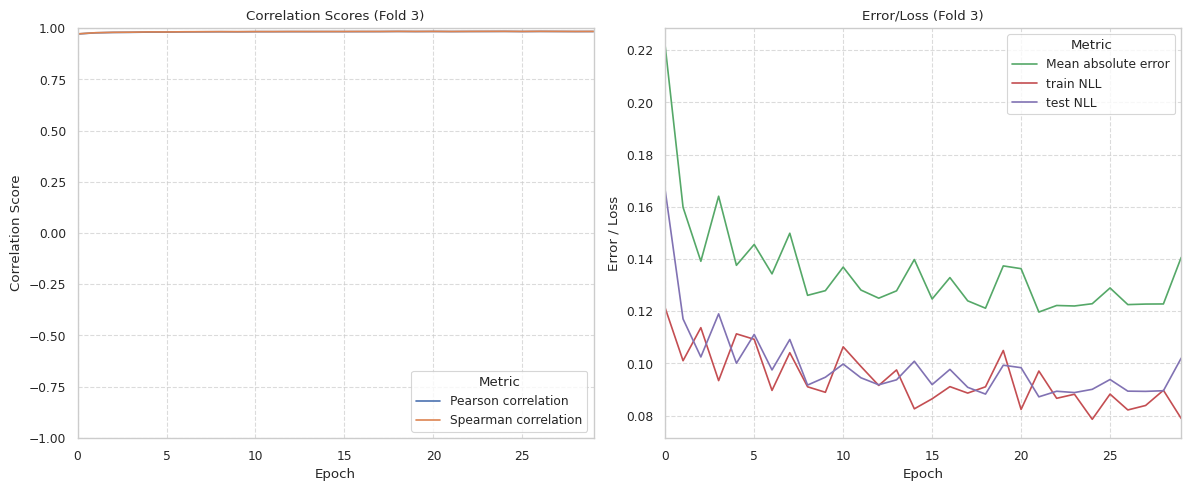

  Saved plot: trained_models/test-2014-30e-5f-smacnp-crps-4000sub/trainingstats_fold4


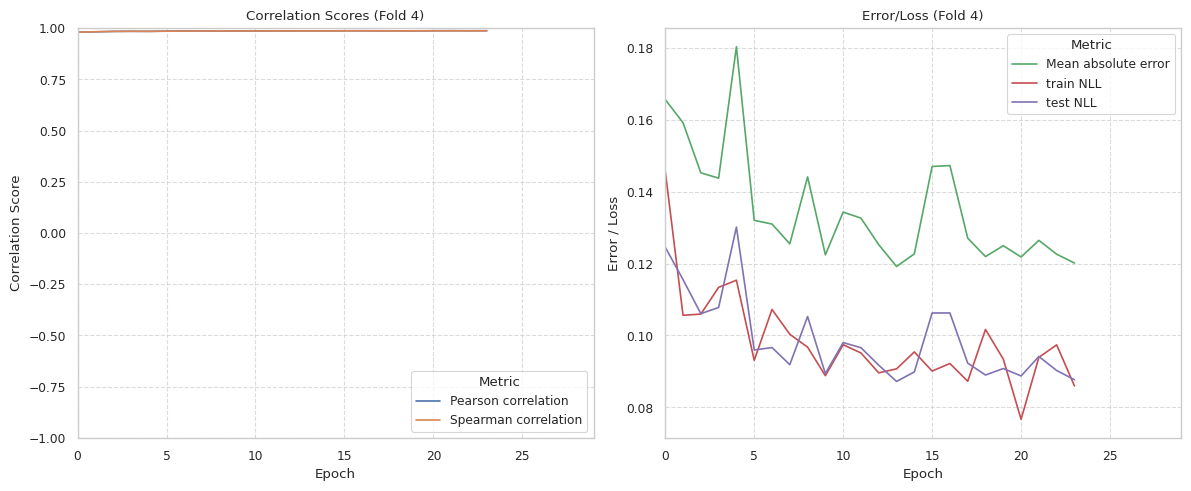

  Saved plot: trained_models/test-2014-30e-5f-smacnp-crps-4000sub/trainingstats_all


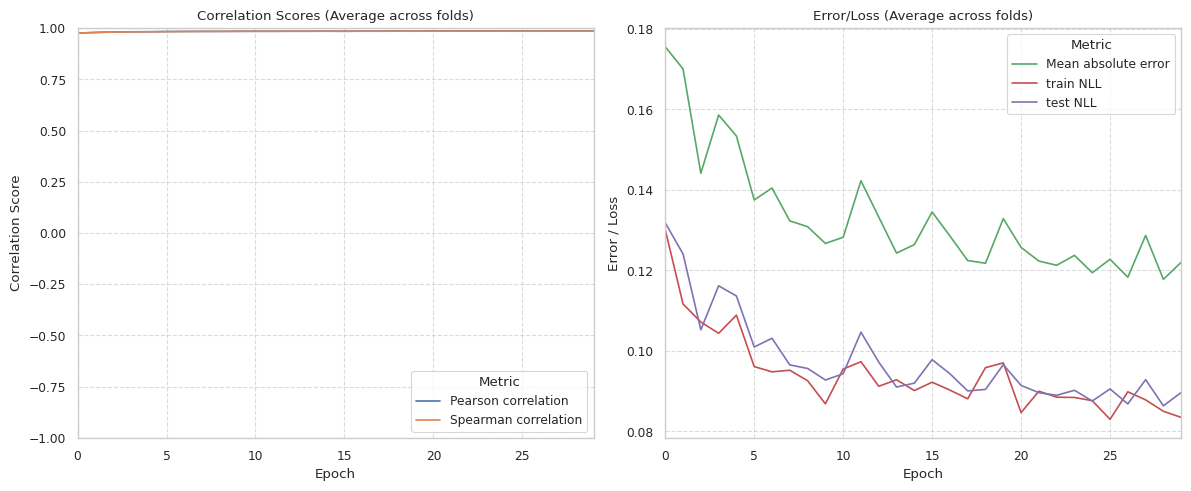

In [ ]:
save_path_prefix = str(output_dir / 'trainingstats')
vis.plot_training_curves(stats, save_path=save_path_prefix)
plt.show()